Actual coordinate-based transect length: 1499.86 m
Assigned plotting distance: -1500 m to 0 m

Processing: No Reef
File: D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu
Selected item: Wave power, p
Requested time: 2017-08-26T02:30:00.000000000
Selected model time: 2017-08-26T02:30:00.000000000
Selected time index: 111

Processing: Barrier Reef
File: D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu
Selected item: Wave power, p
Requested time: 2017-08-26T02:30:00.000000000
Selected model time: 2017-08-26T02:30:00.000000000
Selected time index: 111

Processing: Fringing Reef
File: D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef_v1.sw - Result Files\west_side_fringing_reef_1.5m_v2.dfsu
Selected item: Wave power, p
Requested time: 2017-08-26T02:30:00.000000000

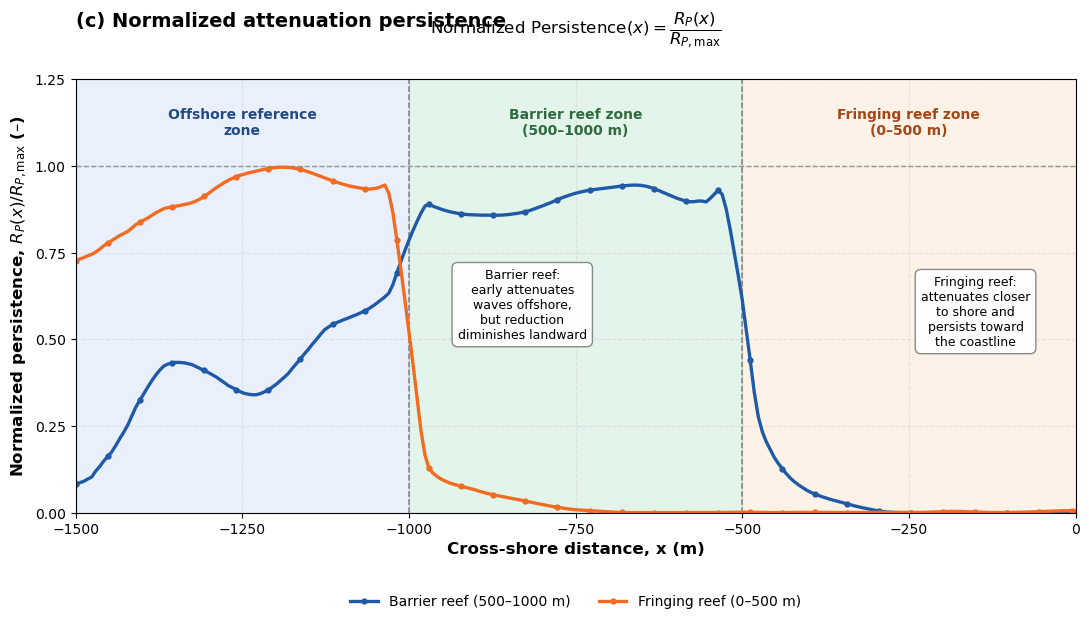

In [2]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# FILE PATHS
# ============================================================

dfsu_barrier = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\West_side_barrier_reef_1.5m_v2.sw - Result Files"
    r"\west_side_barrier_reef_1.5m_v2.dfsu"
)

dfsu_fringing = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\West_side_fringing_reef_v1.sw - Result Files"
    r"\west_side_fringing_reef_1.5m_v2.dfsu"
)

dfsu_no_reef = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files"
    r"\small_scale_wave_result.dfsu"
)

# ============================================================
# USER SETTINGS
# ============================================================

item_name = "Wave power, p"

# West-side transect
x1, y1 = 730446.0, 3174401.0   # Offshore end
x2, y2 = 731495.0, 3175473.0   # Shoreward end

n_points = 250

# Cross-shore coordinate used in the figure
# Offshore = -1500 m, shoreline = 0 m
cross_shore_distance = np.linspace(-1500.0, 0.0, n_points)

# Target time used for spatial comparison
target_time = np.datetime64("2017-08-26T02:30:00")

# Small denominator threshold
power_tolerance = 1.0e-8

# Whether negative reduction values should be retained
# True  = negative values are set to zero before normalization
# False = negative values remain in the profile
clip_negative_reduction = True

# Optional smoothing
apply_smoothing = True
smoothing_window = 9

# Output
output_directory = Path(
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
)

output_figure = output_directory / (
    "West_normalized_wave_power_attenuation_persistence.png"
)

output_excel = output_directory / (
    "West_normalized_wave_power_attenuation_persistence.xlsx"
)

# ============================================================
# CREATE TRANSECT COORDINATES
# ============================================================

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)

xy = np.column_stack((x_line, y_line))

actual_length = np.hypot(x2 - x1, y2 - y1)

print(f"Actual coordinate-based transect length: {actual_length:.2f} m")
print("Assigned plotting distance: -1500 m to 0 m")

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def find_item_name(dfs, requested_item):
    """
    Find the requested DFSU item using exact and partial matching.
    """
    available_items = [item.name for item in dfs.items]

    # Exact case-insensitive match
    for name in available_items:
        if name.strip().lower() == requested_item.strip().lower():
            return name

    # Partial search
    candidates = [
        name for name in available_items
        if "wave" in name.lower() and "power" in name.lower()
    ]

    if len(candidates) == 1:
        print(
            f"Exact item '{requested_item}' was not found. "
            f"Using '{candidates[0]}'."
        )
        return candidates[0]

    raise ValueError(
        f"Could not uniquely identify '{requested_item}'.\n"
        f"Available items:\n{available_items}"
    )


def extract_profile_at_time(
    dfsu_path,
    interpolation_xy,
    requested_time,
    condition_name
):
    """
    Extract wave power along the transect at the model timestep
    nearest to requested_time.
    """
    dfsu_path = Path(dfsu_path)

    if not dfsu_path.exists():
        raise FileNotFoundError(
            f"{condition_name} file was not found:\n{dfsu_path}"
        )

    print("\n" + "=" * 70)
    print(f"Processing: {condition_name}")
    print(f"File: {dfsu_path}")
    print("=" * 70)

    dfs = mikeio.open(str(dfsu_path))

    selected_item = find_item_name(
        dfs,
        item_name
    )

    print(f"Selected item: {selected_item}")

    # Read complete wave-power item
    dataset = dfs.read(
        items=[selected_item]
    )

    model_time = np.array(
        dataset.time,
        dtype="datetime64[ns]"
    )

    requested_time_ns = np.datetime64(
        requested_time,
        "ns"
    )

    # Find timestep nearest to requested time
    time_index = int(
        np.argmin(
            np.abs(model_time - requested_time_ns)
        )
    )

    selected_time = model_time[time_index]

    print(f"Requested time: {requested_time_ns}")
    print(f"Selected model time: {selected_time}")
    print(f"Selected time index: {time_index}")

    # Create interpolation weights for the transect
    elem_ids, weights = dfs.geometry.get_2d_interpolant(
        interpolation_xy
    )

    # Select one timestep from the DataArray
    data_at_time = dataset[0][time_index]

    # Interpolate wave power to transect points
    interpolated = dfs.geometry.interp2d(
        data_at_time,
        elem_ids=elem_ids,
        weights=weights
    )

    profile = np.asarray(
        interpolated
    ).squeeze().astype(float)

    # Ensure one value per extraction point
    if profile.size != len(interpolation_xy):
        raise ValueError(
            f"Unexpected interpolated profile size for "
            f"{condition_name}.\n"
            f"Expected {len(interpolation_xy)} values, "
            f"but obtained {profile.size}."
        )

    # Replace MIKE delete values
    profile[np.abs(profile) > 1.0e30] = np.nan

    return profile, pd.Timestamp(selected_time)


def calculate_wave_power_reduction(
    no_reef_power,
    reef_power,
    tolerance=1.0e-8
):
    """
    Calculate local wave-power reduction relative to no reef:

        Rp(x) = [(P_no reef - P_reef) / P_no reef] * 100
    """
    no_reef_power = np.asarray(
        no_reef_power,
        dtype=float
    )

    reef_power = np.asarray(
        reef_power,
        dtype=float
    )

    reduction = np.full(
        no_reef_power.shape,
        np.nan,
        dtype=float
    )

    valid = (
        np.isfinite(no_reef_power)
        & np.isfinite(reef_power)
        & (np.abs(no_reef_power) > tolerance)
    )

    reduction[valid] = (
        (
            no_reef_power[valid]
            - reef_power[valid]
        )
        / no_reef_power[valid]
    ) * 100.0

    return reduction


def normalize_reduction(reduction):
    """
    Normalize a wave-power reduction profile by its own maximum:

        normalized = Rp(x) / Rp,max
    """
    reduction = np.asarray(
        reduction,
        dtype=float
    )

    if clip_negative_reduction:
        reduction_for_normalization = np.where(
            reduction > 0.0,
            reduction,
            0.0
        )
    else:
        reduction_for_normalization = reduction.copy()

    finite_values = reduction_for_normalization[
        np.isfinite(reduction_for_normalization)
    ]

    if finite_values.size == 0:
        raise ValueError(
            "The reduction profile contains no valid values."
        )

    maximum_reduction = np.nanmax(
        reduction_for_normalization
    )

    if maximum_reduction <= 0.0:
        raise ValueError(
            "The maximum wave-power reduction is zero or negative. "
            "The profile cannot be normalized by a positive maximum."
        )

    normalized = (
        reduction_for_normalization
        / maximum_reduction
    )

    return normalized, maximum_reduction


def smooth_profile(values, window):
    """
    Apply centered rolling-mean smoothing while retaining
    the original profile length.
    """
    if not apply_smoothing:
        return np.asarray(values, dtype=float)

    return (
        pd.Series(values)
        .rolling(
            window=window,
            center=True,
            min_periods=1
        )
        .mean()
        .to_numpy()
    )


# ============================================================
# EXTRACT WAVE-POWER PROFILES
# ============================================================

no_reef_power, no_reef_time = extract_profile_at_time(
    dfsu_path=dfsu_no_reef,
    interpolation_xy=xy,
    requested_time=target_time,
    condition_name="No Reef"
)

barrier_power, barrier_time = extract_profile_at_time(
    dfsu_path=dfsu_barrier,
    interpolation_xy=xy,
    requested_time=target_time,
    condition_name="Barrier Reef"
)

fringing_power, fringing_time = extract_profile_at_time(
    dfsu_path=dfsu_fringing,
    interpolation_xy=xy,
    requested_time=target_time,
    condition_name="Fringing Reef"
)

# Warn if selected times differ
selected_times = {
    no_reef_time,
    barrier_time,
    fringing_time
}

if len(selected_times) > 1:
    print(
        "\nWarning: the nearest selected model times are not "
        "identical among all three files."
    )

# ============================================================
# CALCULATE LOCAL WAVE-POWER REDUCTION
# ============================================================

barrier_reduction = calculate_wave_power_reduction(
    no_reef_power=no_reef_power,
    reef_power=barrier_power,
    tolerance=power_tolerance
)

fringing_reduction = calculate_wave_power_reduction(
    no_reef_power=no_reef_power,
    reef_power=fringing_power,
    tolerance=power_tolerance
)

# ============================================================
# NORMALIZE EACH REEF GEOMETRY BY ITS OWN MAXIMUM
# ============================================================

barrier_normalized, barrier_maximum = normalize_reduction(
    barrier_reduction
)

fringing_normalized, fringing_maximum = normalize_reduction(
    fringing_reduction
)

print("\nMaximum local wave-power reduction")
print(f"Barrier reef:  {barrier_maximum:.2f}%")
print(f"Fringing reef: {fringing_maximum:.2f}%")

# ============================================================
# OPTIONAL SMOOTHING
# ============================================================

barrier_normalized_plot = smooth_profile(
    barrier_normalized,
    smoothing_window
)

fringing_normalized_plot = smooth_profile(
    fringing_normalized,
    smoothing_window
)

# Keep normalized values within 0–1 after smoothing
barrier_normalized_plot = np.clip(
    barrier_normalized_plot,
    0.0,
    1.0
)

fringing_normalized_plot = np.clip(
    fringing_normalized_plot,
    0.0,
    1.0
)

# ============================================================
# SAVE DATA TO EXCEL
# ============================================================

output_directory.mkdir(
    parents=True,
    exist_ok=True
)

results_df = pd.DataFrame(
    {
        "Cross_Shore_Distance_m":
            cross_shore_distance,

        "X":
            x_line,

        "Y":
            y_line,

        "No_Reef_Wave_Power":
            no_reef_power,

        "Barrier_Wave_Power":
            barrier_power,

        "Fringing_Wave_Power":
            fringing_power,

        "Barrier_Reduction_Percent":
            barrier_reduction,

        "Fringing_Reduction_Percent":
            fringing_reduction,

        "Barrier_Normalized_Persistence":
            barrier_normalized,

        "Fringing_Normalized_Persistence":
            fringing_normalized,

        "Barrier_Normalized_Smoothed":
            barrier_normalized_plot,

        "Fringing_Normalized_Smoothed":
            fringing_normalized_plot,
    }
)

summary_df = pd.DataFrame(
    {
        "Scenario": [
            "Barrier Reef",
            "Fringing Reef"
        ],

        "Maximum_Reduction_Percent": [
            barrier_maximum,
            fringing_maximum
        ],

        "Selected_Time": [
            barrier_time,
            fringing_time
        ]
    }
)

with pd.ExcelWriter(
    output_excel,
    engine="openpyxl"
) as writer:

    results_df.to_excel(
        writer,
        sheet_name="Cross_Shore_Profiles",
        index=False
    )

    summary_df.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )

print(f"\nExcel file saved to:\n{output_excel}")

# ============================================================
# PLOT NORMALIZED ATTENUATION PERSISTENCE
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 6.5)
)

# ------------------------------------------------------------
# Evaluation-zone shading
# ------------------------------------------------------------

# Offshore reference zone
ax.axvspan(
    -1500,
    -1000,
    alpha=0.14,
    color="cornflowerblue"
)

# Barrier reef zone
ax.axvspan(
    -1000,
    -500,
    alpha=0.14,
    color="mediumseagreen"
)

# Fringing reef zone
ax.axvspan(
    -500,
    0,
    alpha=0.14,
    color="sandybrown"
)

# Zone boundaries
ax.axvline(
    -1000,
    linestyle="--",
    linewidth=1.1,
    color="gray"
)

ax.axvline(
    -500,
    linestyle="--",
    linewidth=1.1,
    color="gray"
)

# Reference at normalized maximum
ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.0,
    color="gray",
    alpha=0.8
)

# ------------------------------------------------------------
# Profiles
# ------------------------------------------------------------

ax.plot(
    cross_shore_distance,
    barrier_normalized_plot,
    color="#1f5aa6",
    linewidth=2.4,
    marker="o",
    markersize=3.5,
    markevery=8,
    label="Barrier reef (500–1000 m)"
)

ax.plot(
    cross_shore_distance,
    fringing_normalized_plot,
    color="#f26b21",
    linewidth=2.4,
    marker="o",
    markersize=3.5,
    markevery=8,
    label="Fringing reef (0–500 m)"
)

# ------------------------------------------------------------
# Zone labels
# ------------------------------------------------------------

ax.text(
    -1250,
    1.17,
    "Offshore reference\nzone",
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color="#234a84"
)

ax.text(
    -750,
    1.17,
    "Barrier reef zone\n(500–1000 m)",
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color="#2f6b3f"
)

ax.text(
    -250,
    1.17,
    "Fringing reef zone\n(0–500 m)",
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color="#a44716"
)

# ------------------------------------------------------------
# Annotation boxes
# ------------------------------------------------------------

ax.text(
    -830,
    0.60,
    "Barrier reef:\nearly attenuates\nwaves offshore,\nbut reduction\ndiminishes landward",
    fontsize=9,
    ha="center",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="white",
        edgecolor="gray",
        alpha=0.92
    )
)

ax.text(
    -150,
    0.58,
    "Fringing reef:\nattenuates closer\nto shore and\npersists toward\nthe coastline",
    fontsize=9,
    ha="center",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="white",
        edgecolor="gray",
        alpha=0.92
    )
)

# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.set_xlim(
    -1500,
    0
)

ax.set_ylim(
    0,
    1.25
)

ax.set_xticks(
    [-1500, -1250, -1000, -750, -500, -250, 0]
)

ax.set_yticks(
    np.arange(0.0, 1.26, 0.25)
)

ax.set_xlabel(
    "Cross-shore distance, x (m)",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    r"Normalized persistence, $R_P(x)/R_{P,\max}$ (–)",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "(c) Normalized attenuation persistence",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=38
)

# Formula above plot
ax.text(
    0.5,
    1.07,
    r"Normalized Persistence$(x)"
    r"=\dfrac{R_P(x)}{R_{P,\max}}$",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=12
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.25
)

ax.tick_params(
    axis="both",
    labelsize=10
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=False,
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    output_figure,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# print(f"Figure saved to:\n{output_figure}")

Actual coordinate-based length: 1499.86 m
Assigned analysis length: 0–1500 m
Extraction points: 250

Processing: No Reef
File: D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu
Selected item: Wave power, p
Requested time: 2017-08-26T02:30:00.000000000
Selected time:  2017-08-26T02:30:00.000000000
Time index:     111

Processing: Barrier Reef
File: D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu
Selected item: Wave power, p
Requested time: 2017-08-26T02:30:00.000000000
Selected time:  2017-08-26T02:30:00.000000000
Time index:     111

Processing: Fringing Reef
File: D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef_v1.sw - Result Files\west_side_fringing_reef_1.5m_v2.dfsu
Selected item: Wave power, p
Requested time: 2017-08-26T02:30:00.000000000
Selected time

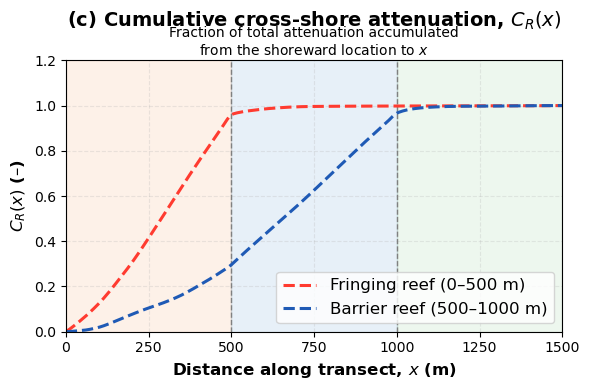

In [19]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# FILE PATHS
# ============================================================

dfsu_barrier = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\West_side_barrier_reef_1.5m_v2.sw - Result Files"
    r"\west_side_barrier_reef_1.5m_v2.dfsu"
)

dfsu_fringing = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\West_side_fringing_reef_v1.sw - Result Files"
    r"\west_side_fringing_reef_1.5m_v2.dfsu"
)

dfsu_no_reef = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files"
    r"\small_scale_wave_result.dfsu"
)

# ============================================================
# USER SETTINGS
# ============================================================

item_name = "Wave power, p"

# Transect coordinates
# First point = shoreline/nearshore end, assigned x = 0 m
# Second point = offshore end, assigned x = 1500 m
x1, y1 = 730446.0, 3174401.0
x2, y2 = 731495.0, 3175473.0

n_points = 250
transect_length = 1500.0

# Target model time
target_time = np.datetime64("2017-08-26T02:30:00")

# Optional smoothing of cumulative curves
apply_smoothing = False
smoothing_window = 7

# Output directory
output_directory = Path(
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
)

output_figure = output_directory / (
    "West_cumulative_cross_shore_attenuation.png"
)

output_excel = output_directory / (
    "West_cumulative_cross_shore_attenuation.xlsx"
)

# ============================================================
# CREATE TRANSECT
# ============================================================

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)

xy = np.column_stack((x_line, y_line))

# Distance coordinate required by the equation: 0–1500 m
distance = np.linspace(
    0.0,
    transect_length,
    n_points
)

actual_length = np.hypot(
    x2 - x1,
    y2 - y1
)

print(f"Actual coordinate-based length: {actual_length:.2f} m")
print(f"Assigned analysis length: 0–{transect_length:.0f} m")
print(f"Extraction points: {n_points}")

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def find_item_name(dfs, requested_item):
    """
    Find the requested DFSU item using exact or partial matching.
    """
    available_items = [
        item.name for item in dfs.items
    ]

    # Exact case-insensitive match
    for name in available_items:
        if name.strip().lower() == requested_item.strip().lower():
            return name

    # Partial match
    candidates = [
        name for name in available_items
        if (
            "wave" in name.lower()
            and "power" in name.lower()
        )
    ]

    if len(candidates) == 1:
        print(
            f"Exact item '{requested_item}' was not found. "
            f"Using '{candidates[0]}'."
        )
        return candidates[0]

    raise ValueError(
        f"Could not uniquely identify '{requested_item}'.\n"
        f"Available items are:\n{available_items}"
    )


def extract_wave_power_profile(
    dfsu_path,
    interpolation_points,
    requested_time,
    scenario_name
):
    """
    Extract wave power along the transect at the timestep nearest
    to the requested time.
    """
    dfsu_path = Path(dfsu_path)

    if not dfsu_path.exists():
        raise FileNotFoundError(
            f"{scenario_name} file was not found:\n{dfsu_path}"
        )

    print("\n" + "=" * 72)
    print(f"Processing: {scenario_name}")
    print(f"File: {dfsu_path}")
    print("=" * 72)

    dfs = mikeio.open(
        str(dfsu_path)
    )

    selected_item = find_item_name(
        dfs,
        item_name
    )

    print(f"Selected item: {selected_item}")

    # Read wave-power data
    dataset = dfs.read(
        items=[selected_item]
    )

    model_time = np.asarray(
        dataset.time,
        dtype="datetime64[ns]"
    )

    requested_time_ns = np.datetime64(
        requested_time,
        "ns"
    )

    # Nearest model timestep
    time_index = int(
        np.argmin(
            np.abs(
                model_time - requested_time_ns
            )
        )
    )

    selected_time = model_time[time_index]

    print(f"Requested time: {requested_time_ns}")
    print(f"Selected time:  {selected_time}")
    print(f"Time index:     {time_index}")

    # Spatial interpolation weights
    elem_ids, weights = (
        dfs.geometry.get_2d_interpolant(
            interpolation_points
        )
    )

    # Select the requested timestep
    data_at_time = dataset[0][time_index]

    # Interpolate to the 250 transect points
    interpolated = dfs.geometry.interp2d(
        data_at_time,
        elem_ids=elem_ids,
        weights=weights
    )

    profile = np.asarray(
        interpolated
    ).squeeze().astype(float)

    if profile.size != len(interpolation_points):
        raise ValueError(
            f"Unexpected profile size for {scenario_name}.\n"
            f"Expected {len(interpolation_points)} values, "
            f"but obtained {profile.size}."
        )

    # Replace MIKE delete values
    profile[
        np.abs(profile) > 1.0e30
    ] = np.nan

    return profile, pd.Timestamp(selected_time)


def fill_profile_gaps(values):
    """
    Fill isolated NaN values by linear interpolation along
    the transect.
    """
    series = pd.Series(
        np.asarray(values, dtype=float)
    )

    return (
        series
        .interpolate(
            method="linear",
            limit_direction="both"
        )
        .to_numpy()
    )


def cumulative_trapezoidal_integral(y, x):
    """
    Calculate cumulative trapezoidal integration without
    requiring scipy.

    Returns an array with the same length as x and y.
    The first cumulative value is zero.
    """
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)

    if len(y) != len(x):
        raise ValueError(
            "The x and y arrays must have the same length."
        )

    segment_areas = (
        0.5
        * (y[1:] + y[:-1])
        * np.diff(x)
    )

    cumulative = np.concatenate(
        (
            [0.0],
            np.cumsum(segment_areas)
        )
    )

    return cumulative


def calculate_cumulative_attenuation(
    no_reef_power,
    reef_power,
    cross_shore_distance
):
    """
    Calculate:

                 integral from 0 to x |P_no reef - P_reef| ds
        C_R(x) = ------------------------------------------------
                 integral from 0 to L |P_no reef - P_reef| ds
    """
    no_reef_power = fill_profile_gaps(
        no_reef_power
    )

    reef_power = fill_profile_gaps(
        reef_power
    )

    # Absolute local attenuation magnitude
    local_attenuation = np.abs(
        no_reef_power - reef_power
    )

    # Numerator: cumulative integral from 0 to x
    cumulative_integral = cumulative_trapezoidal_integral(
        y=local_attenuation,
        x=cross_shore_distance
    )

    # Denominator: total integral from 0 to 1500 m
    total_integral = cumulative_integral[-1]

    if (
        not np.isfinite(total_integral)
        or total_integral <= 0.0
    ):
        raise ValueError(
            "The total integrated attenuation is zero or invalid."
        )

    normalized_cumulative = (
        cumulative_integral
        / total_integral
    )

    return (
        normalized_cumulative,
        local_attenuation,
        cumulative_integral,
        total_integral
    )


def smooth_curve(values, window):
    """
    Optional centered rolling-mean smoothing.
    """
    if not apply_smoothing:
        return np.asarray(values, dtype=float)

    return (
        pd.Series(values)
        .rolling(
            window=window,
            center=True,
            min_periods=1
        )
        .mean()
        .to_numpy()
    )


def distance_at_fraction(cumulative_curve, distance_array, fraction):
    """
    Estimate the cross-shore distance where a selected fraction
    of cumulative attenuation has been achieved.
    """
    curve = np.asarray(
        cumulative_curve,
        dtype=float
    )

    x = np.asarray(
        distance_array,
        dtype=float
    )

    return np.interp(
        fraction,
        curve,
        x
    )


# ============================================================
# EXTRACT WAVE-POWER PROFILES
# ============================================================

no_reef_power, no_reef_time = extract_wave_power_profile(
    dfsu_path=dfsu_no_reef,
    interpolation_points=xy,
    requested_time=target_time,
    scenario_name="No Reef"
)

barrier_power, barrier_time = extract_wave_power_profile(
    dfsu_path=dfsu_barrier,
    interpolation_points=xy,
    requested_time=target_time,
    scenario_name="Barrier Reef"
)

fringing_power, fringing_time = extract_wave_power_profile(
    dfsu_path=dfsu_fringing,
    interpolation_points=xy,
    requested_time=target_time,
    scenario_name="Fringing Reef"
)

# Check model times
selected_times = {
    no_reef_time,
    barrier_time,
    fringing_time
}

if len(selected_times) > 1:
    print(
        "\nWarning: nearest selected timesteps differ among "
        "the three DFSU files."
    )

# ============================================================
# CALCULATE CUMULATIVE CROSS-SHORE ATTENUATION
# ============================================================

(
    barrier_cumulative,
    barrier_local_attenuation,
    barrier_cumulative_integral,
    barrier_total_integral
) = calculate_cumulative_attenuation(
    no_reef_power=no_reef_power,
    reef_power=barrier_power,
    cross_shore_distance=distance
)

(
    fringing_cumulative,
    fringing_local_attenuation,
    fringing_cumulative_integral,
    fringing_total_integral
) = calculate_cumulative_attenuation(
    no_reef_power=no_reef_power,
    reef_power=fringing_power,
    cross_shore_distance=distance
)

# Optional smoothing only for visualization
barrier_plot = smooth_curve(
    barrier_cumulative,
    smoothing_window
)

fringing_plot = smooth_curve(
    fringing_cumulative,
    smoothing_window
)

# Ensure cumulative curves remain between 0 and 1
barrier_plot = np.clip(
    barrier_plot,
    0.0,
    1.0
)

fringing_plot = np.clip(
    fringing_plot,
    0.0,
    1.0
)

# Ensure curves are nondecreasing after optional smoothing
barrier_plot = np.maximum.accumulate(
    barrier_plot
)

fringing_plot = np.maximum.accumulate(
    fringing_plot
)

# ============================================================
# CALCULATE USEFUL CUMULATIVE DISTANCE METRICS
# ============================================================

barrier_x50 = distance_at_fraction(
    barrier_cumulative,
    distance,
    0.50
)

barrier_x80 = distance_at_fraction(
    barrier_cumulative,
    distance,
    0.80
)

barrier_x90 = distance_at_fraction(
    barrier_cumulative,
    distance,
    0.90
)

fringing_x50 = distance_at_fraction(
    fringing_cumulative,
    distance,
    0.50
)

fringing_x80 = distance_at_fraction(
    fringing_cumulative,
    distance,
    0.80
)

fringing_x90 = distance_at_fraction(
    fringing_cumulative,
    distance,
    0.90
)

print("\nCumulative attenuation distances")
print("-" * 50)
print(
    f"Barrier reef:  "
    f"x50 = {barrier_x50:.1f} m, "
    f"x80 = {barrier_x80:.1f} m, "
    f"x90 = {barrier_x90:.1f} m"
)
print(
    f"Fringing reef: "
    f"x50 = {fringing_x50:.1f} m, "
    f"x80 = {fringing_x80:.1f} m, "
    f"x90 = {fringing_x90:.1f} m"
)

# ============================================================
# SAVE DATA TO EXCEL
# ============================================================

output_directory.mkdir(
    parents=True,
    exist_ok=True
)

results_df = pd.DataFrame(
    {
        "Distance_m":
            distance,

        "X":
            x_line,

        "Y":
            y_line,

        "No_Reef_Wave_Power":
            no_reef_power,

        "Barrier_Wave_Power":
            barrier_power,

        "Fringing_Wave_Power":
            fringing_power,

        "Barrier_Absolute_Local_Attenuation":
            barrier_local_attenuation,

        "Fringing_Absolute_Local_Attenuation":
            fringing_local_attenuation,

        "Barrier_Cumulative_Integral":
            barrier_cumulative_integral,

        "Fringing_Cumulative_Integral":
            fringing_cumulative_integral,

        "Barrier_Cumulative_Attenuation":
            barrier_cumulative,

        "Fringing_Cumulative_Attenuation":
            fringing_cumulative,
    }
)

summary_df = pd.DataFrame(
    {
        "Metric": [
            "Selected no-reef time",
            "Selected barrier-reef time",
            "Selected fringing-reef time",
            "Barrier total integrated attenuation",
            "Fringing total integrated attenuation",
            "Barrier x50 (m)",
            "Barrier x80 (m)",
            "Barrier x90 (m)",
            "Fringing x50 (m)",
            "Fringing x80 (m)",
            "Fringing x90 (m)",
        ],

        "Value": [
            str(no_reef_time),
            str(barrier_time),
            str(fringing_time),
            barrier_total_integral,
            fringing_total_integral,
            barrier_x50,
            barrier_x80,
            barrier_x90,
            fringing_x50,
            fringing_x80,
            fringing_x90,
        ]
    }
)

with pd.ExcelWriter(
    output_excel,
    engine="openpyxl"
) as writer:

    results_df.to_excel(
        writer,
        sheet_name="Cross_Shore_Results",
        index=False
    )

    summary_df.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )

print(f"\nExcel file saved to:\n{output_excel}")

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 4)
)

# ------------------------------------------------------------
# Zone shading
# ------------------------------------------------------------

# Fringing reef zone: 0–500 m
ax.axvspan(
    0,
    500,
    color="#f4a261",
    alpha=0.14
)

# Barrier reef zone: 500–1000 m
ax.axvspan(
    500,
    1000,
    color="#6aa5d9",
    alpha=0.16
)

# Offshore reference zone: 1000–1500 m
ax.axvspan(
    1000,
    1500,
    color="#82c987",
    alpha=0.14
)

# Zone boundaries
ax.axvline(
    500,
    linestyle="--",
    linewidth=1.0,
    color="gray"
)

ax.axvline(
    1000,
    linestyle="--",
    linewidth=1.0,
    color="gray"
)

# ------------------------------------------------------------
# Cumulative curves
# ------------------------------------------------------------

ax.plot(
    distance,
    fringing_plot,
    linestyle="--",
    linewidth=2.2,
    color="#ff3b30",
    label="Fringing reef (0–500 m)"
)

ax.plot(
    distance,
    barrier_plot,
    linestyle="--",
    linewidth=2.2,
    color="#1f5ab5",
    label="Barrier reef (500–1000 m)"
)

# ------------------------------------------------------------
# Zone labels
# ------------------------------------------------------------

# ax.text(
#     250,
#     1.10,
#     "Fringing reef\n(0–500 m)",
#     ha="center",
#     va="top",
#     fontsize=10,
#     fontweight="bold",
#     color="#d6271f"
# )

# ax.text(
#     750,
#     1.10,
#     "Barrier reef\n(500–1000 m)",
#     ha="center",
#     va="top",
#     fontsize=10,
#     fontweight="bold",
#     color="#1f4f99"
# )

# ax.text(
#     1250,
#     1.10,
#     "Offshore reference\n(1000–1500 m)",
#     ha="center",
#     va="top",
#     fontsize=10,
#     fontweight="bold",
#     color="#3b7f40"
# )

# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.set_xlim(
    0,
    1500
)

ax.set_ylim(
    0,
    1.20
)

ax.set_xticks(
    np.arange(
        0,
        1501,
        250
    )
)

ax.set_yticks(
    np.arange(
        0,
        1.21,
        0.20
    )
)

ax.set_xlabel(
    "Distance along transect, $x$ (m)",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    r"$C_R(x)$ (–)",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "(c) Cumulative cross-shore attenuation, "
    r"$C_R(x)$",
    fontsize=14,
    fontweight="bold",
    pad=24
)

ax.text(
    0.5,
    1.01,
    "Fraction of total attenuation accumulated\n"
    "from the shoreward location to $x$",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.25
)

ax.legend(
    loc="lower right",
    frameon=True,
    fontsize=12
)

ax.tick_params(
    axis="both",
    labelsize=10
)

plt.tight_layout()

# plt.savefig(
#     output_figure,
#     dpi=600,
#     bbox_inches="tight"
# )

plt.show()

# print(f"Figure saved to:\n{output_figure}")

Coordinate-based transect length: 1499.86 m
Assigned analysis length: 0–1500 m
Number of extraction points: 250

Processing: No Reef
File: D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu
Selected item: Wave power, p
Selected start: 2017-08-25 00:00:00
Selected end:   2017-08-27 00:00:00
Selected timesteps: 97

Processing: Barrier Reef
File: D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu
Selected item: Wave power, p
Selected start: 2017-08-25 00:00:00
Selected end:   2017-08-27 00:00:00
Selected timesteps: 97

Processing: Fringing Reef
File: D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef_v1.sw - Result Files\west_side_fringing_reef_1.5m_v2.dfsu
Selected item: Wave power, p
Selected start: 2017-08-25 00:00:00
Selected end:   2017-08-27 00:00:00
Selected 

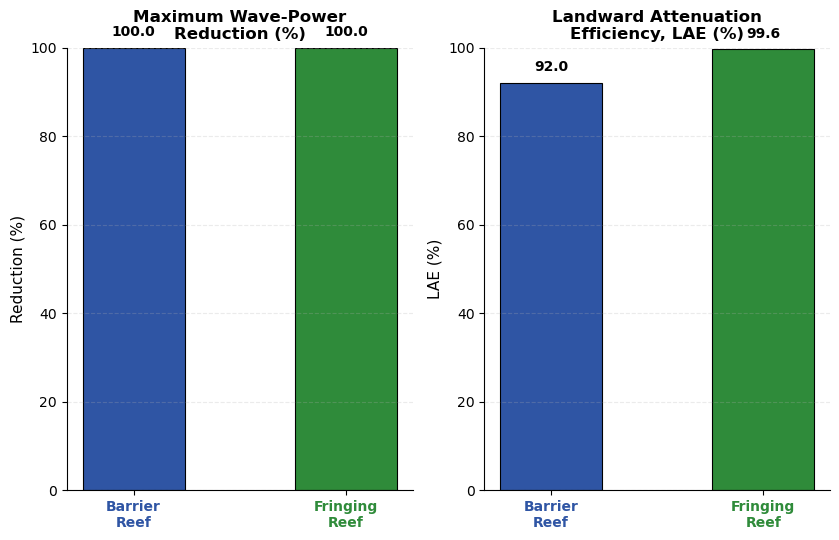

Figure saved to:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_Maximum_Reduction_and_LAE.png


In [5]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# FILE PATHS
# ============================================================

dfsu_barrier = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\West_side_barrier_reef_1.5m_v2.sw - Result Files"
    r"\west_side_barrier_reef_1.5m_v2.dfsu"
)

dfsu_fringing = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\West_side_fringing_reef_v1.sw - Result Files"
    r"\west_side_fringing_reef_1.5m_v2.dfsu"
)

dfsu_no_reef = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files"
    r"\small_scale_wave_result.dfsu"
)

# ============================================================
# USER SETTINGS
# ============================================================

item_name = "Wave power, p"

# West-side transect
# First coordinate = coastline/shoreward end = x = 0 m
# Second coordinate = offshore end = x = 1500 m
x1, y1 = 730446.0, 3174401.0
x2, y2 = 731495.0, 3175473.0

n_points = 250
transect_length_m = 1500.0

# Distance from reef crest to coastline
L_land_barrier = 1000.0
L_land_fringing = 500.0

# Storm-analysis period
start_time = np.datetime64("2017-08-25T00:00")
end_time = np.datetime64("2017-08-27T00:00")

# Prevent division by very small no-reef wave-power values
denominator_tolerance = 1.0e-8

# True means only beneficial reduction is included.
# Negative values, representing local amplification, become zero.
clip_negative_reduction = True

# Optional maximum physical limit
# Percentage reductions greater than 100% are usually numerical artifacts.
clip_above_100 = True

# ============================================================
# OUTPUT FILES
# ============================================================

output_directory = Path(
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
)

output_figure = output_directory / (
    "West_Maximum_Reduction_and_LAE.png"
)

output_excel = output_directory / (
    "West_Maximum_Reduction_and_LAE.xlsx"
)

# ============================================================
# CREATE TRANSECT
# ============================================================

x_coordinates = np.linspace(x1, x2, n_points)
y_coordinates = np.linspace(y1, y2, n_points)

xy = np.column_stack(
    (x_coordinates, y_coordinates)
)

# Assigned cross-shore distance
distance = np.linspace(
    0.0,
    transect_length_m,
    n_points
)

actual_length = np.hypot(
    x2 - x1,
    y2 - y1
)

print(f"Coordinate-based transect length: {actual_length:.2f} m")
print(f"Assigned analysis length: 0–{transect_length_m:.0f} m")
print(f"Number of extraction points: {n_points}")

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def find_wave_power_item(dfs, requested_item):
    """
    Find the wave-power item using exact and partial matching.
    """
    available_items = [
        item.name for item in dfs.items
    ]

    # Exact case-insensitive match
    for name in available_items:
        if name.strip().lower() == requested_item.strip().lower():
            return name

    # Partial match
    candidates = [
        name for name in available_items
        if (
            "wave" in name.lower()
            and "power" in name.lower()
        )
    ]

    if len(candidates) == 1:
        print(
            f"Exact item '{requested_item}' not found. "
            f"Using '{candidates[0]}'."
        )
        return candidates[0]

    raise ValueError(
        f"Could not uniquely identify '{requested_item}'.\n"
        f"Available items:\n{available_items}"
    )


def standardize_time_point_array(
    values,
    number_of_times,
    number_of_points
):
    """
    Convert interpolation output to:

        rows    = timesteps
        columns = transect points
    """
    values = np.asarray(values)
    values = np.squeeze(values)

    if values.ndim == 1:

        if (
            number_of_times == 1
            and values.size == number_of_points
        ):
            return values.reshape(
                1,
                number_of_points
            )

        if (
            number_of_points == 1
            and values.size == number_of_times
        ):
            return values.reshape(
                number_of_times,
                1
            )

        raise ValueError(
            "Unexpected one-dimensional interpolation result.\n"
            f"Shape: {values.shape}"
        )

    if values.ndim != 2:
        raise ValueError(
            "Unexpected interpolation dimensions.\n"
            f"Shape: {values.shape}"
        )

    if values.shape == (
        number_of_times,
        number_of_points
    ):
        return values

    if values.shape == (
        number_of_points,
        number_of_times
    ):
        return values.T

    raise ValueError(
        "Could not identify time and point dimensions.\n"
        f"Actual shape: {values.shape}\n"
        f"Expected ({number_of_times}, {number_of_points}) "
        f"or ({number_of_points}, {number_of_times})"
    )


def extract_wave_power_timeseries(
    dfsu_path,
    interpolation_points,
    scenario_name
):
    """
    Extract wave-power time series at all 250 transect points
    and retain the specified analysis period.
    """
    dfsu_path = Path(dfsu_path)

    if not dfsu_path.exists():
        raise FileNotFoundError(
            f"{scenario_name} file was not found:\n{dfsu_path}"
        )

    print("\n" + "=" * 72)
    print(f"Processing: {scenario_name}")
    print(f"File: {dfsu_path}")
    print("=" * 72)

    dfs = mikeio.open(
        str(dfsu_path)
    )

    selected_item = find_wave_power_item(
        dfs,
        item_name
    )

    print(f"Selected item: {selected_item}")

    dataset = dfs.read(
        items=[selected_item]
    )

    model_time = pd.DatetimeIndex(
        dataset.time
    )

    start_timestamp = pd.Timestamp(start_time)
    end_timestamp = pd.Timestamp(end_time)

    time_mask = (
        (model_time >= start_timestamp)
        & (model_time <= end_timestamp)
    )

    time_indices = np.where(time_mask)[0]

    if len(time_indices) == 0:
        raise ValueError(
            f"No timesteps exist between {start_timestamp} "
            f"and {end_timestamp} for {scenario_name}."
        )

    print(f"Selected start: {model_time[time_indices[0]]}")
    print(f"Selected end:   {model_time[time_indices[-1]]}")
    print(f"Selected timesteps: {len(time_indices)}")

    # Create spatial interpolation information
    elem_ids, weights = (
        dfs.geometry.get_2d_interpolant(
            interpolation_points
        )
    )

    # Interpolate all timesteps to all transect points
    interpolated = dfs.geometry.interp2d(
        dataset[0],
        elem_ids=elem_ids,
        weights=weights
    )

    wave_power = standardize_time_point_array(
        values=interpolated,
        number_of_times=len(model_time),
        number_of_points=len(interpolation_points)
    )

    wave_power = wave_power.astype(float)

    # Replace MIKE delete values
    wave_power[
        np.abs(wave_power) > 1.0e30
    ] = np.nan

    selected_wave_power = wave_power[
        time_indices,
        :
    ]

    selected_time = model_time[
        time_indices
    ]

    columns = [
        f"P{i + 1:03d}"
        for i in range(n_points)
    ]

    result = pd.DataFrame(
        selected_wave_power,
        index=selected_time,
        columns=columns
    )

    result.index.name = "Time"

    return result


def align_three_scenarios(
    no_reef,
    barrier,
    fringing
):
    """
    Align all simulations using common timestamps.
    """
    common_time = (
        no_reef.index
        .intersection(barrier.index)
        .intersection(fringing.index)
    )

    if len(common_time) == 0:
        raise ValueError(
            "The three simulations have no common timestamps."
        )

    return (
        no_reef.loc[common_time].copy(),
        barrier.loc[common_time].copy(),
        fringing.loc[common_time].copy(),
        common_time
    )


def calculate_reduction_matrix(
    no_reef_power,
    reef_power,
    tolerance
):
    """
    Calculate local wave-power reduction at every timestep
    and transect point:

        Rp(x,t) = [(P_no reef - P_reef) / P_no reef] * 100
    """
    no_reef_array = no_reef_power.to_numpy(
        dtype=float
    )

    reef_array = reef_power.to_numpy(
        dtype=float
    )

    reduction = np.full_like(
        no_reef_array,
        np.nan,
        dtype=float
    )

    valid = (
        np.isfinite(no_reef_array)
        & np.isfinite(reef_array)
        & (np.abs(no_reef_array) > tolerance)
    )

    reduction[valid] = (
        (
            no_reef_array[valid]
            - reef_array[valid]
        )
        / no_reef_array[valid]
    ) * 100.0

    if clip_negative_reduction:
        reduction = np.where(
            np.isfinite(reduction),
            np.maximum(reduction, 0.0),
            np.nan
        )

    if clip_above_100:
        reduction = np.where(
            np.isfinite(reduction),
            np.minimum(reduction, 100.0),
            np.nan
        )

    return reduction


def calculate_maximum_reduction_profile(
    reduction_matrix
):
    """
    At every transect point calculate:

        Rp,max(x) = maximum over time of Rp(x,t)
    """
    with np.errstate(
        all="ignore"
    ):
        maximum_profile = np.nanmax(
            reduction_matrix,
            axis=0
        )

    return maximum_profile


def calculate_lae(
    maximum_reduction_profile,
    profile_distance,
    landward_length
):
    """
    Calculate:

              1
        LAE = ------ integral[0 to L_land] Rp,max(x) dx
             L_land
    """
    profile_distance = np.asarray(
        profile_distance,
        dtype=float
    )

    maximum_reduction_profile = np.asarray(
        maximum_reduction_profile,
        dtype=float
    )

    # Include values inside landward zone
    zone_mask = (
        (profile_distance >= 0.0)
        & (profile_distance <= landward_length)
    )

    zone_distance = profile_distance[
        zone_mask
    ]

    zone_reduction = maximum_reduction_profile[
        zone_mask
    ]

    # Remove invalid pairs
    valid = (
        np.isfinite(zone_distance)
        & np.isfinite(zone_reduction)
    )

    zone_distance = zone_distance[
        valid
    ]

    zone_reduction = zone_reduction[
        valid
    ]

    if len(zone_distance) < 2:
        raise ValueError(
            f"Insufficient valid points in the 0–"
            f"{landward_length:.0f} m zone."
        )

    # Add an interpolated endpoint exactly at L_land if needed
    if not np.isclose(
        zone_distance[-1],
        landward_length
    ):
        endpoint_value = np.interp(
            landward_length,
            profile_distance[
                np.isfinite(maximum_reduction_profile)
            ],
            maximum_reduction_profile[
                np.isfinite(maximum_reduction_profile)
            ]
        )

        zone_distance = np.append(
            zone_distance,
            landward_length
        )

        zone_reduction = np.append(
            zone_reduction,
            endpoint_value
        )

    # Spatial trapezoidal integration
    integrated_reduction = np.trapz(
        y=zone_reduction,
        x=zone_distance
    )

    lae = (
        integrated_reduction
        / landward_length
    )

    return (
        lae,
        integrated_reduction,
        zone_mask
    )


# ============================================================
# EXTRACT WAVE-POWER TIME SERIES
# ============================================================

no_reef_timeseries = extract_wave_power_timeseries(
    dfsu_path=dfsu_no_reef,
    interpolation_points=xy,
    scenario_name="No Reef"
)

barrier_timeseries = extract_wave_power_timeseries(
    dfsu_path=dfsu_barrier,
    interpolation_points=xy,
    scenario_name="Barrier Reef"
)

fringing_timeseries = extract_wave_power_timeseries(
    dfsu_path=dfsu_fringing,
    interpolation_points=xy,
    scenario_name="Fringing Reef"
)

# Align common timestamps
(
    no_reef_aligned,
    barrier_aligned,
    fringing_aligned,
    common_time
) = align_three_scenarios(
    no_reef=no_reef_timeseries,
    barrier=barrier_timeseries,
    fringing=fringing_timeseries
)

print("\nCommon comparison period")
print(f"Start: {common_time[0]}")
print(f"End:   {common_time[-1]}")
print(f"Timesteps: {len(common_time)}")

# ============================================================
# CALCULATE LOCAL REDUCTION MATRICES
# ============================================================

barrier_reduction_matrix = calculate_reduction_matrix(
    no_reef_power=no_reef_aligned,
    reef_power=barrier_aligned,
    tolerance=denominator_tolerance
)

fringing_reduction_matrix = calculate_reduction_matrix(
    no_reef_power=no_reef_aligned,
    reef_power=fringing_aligned,
    tolerance=denominator_tolerance
)

# ============================================================
# MAXIMUM TEMPORAL REDUCTION PROFILE
# ============================================================

barrier_Rp_max = calculate_maximum_reduction_profile(
    barrier_reduction_matrix
)

fringing_Rp_max = calculate_maximum_reduction_profile(
    fringing_reduction_matrix
)

# Overall maximum reduction achieved by each geometry
barrier_maximum_reduction = np.nanmax(
    barrier_Rp_max
)

fringing_maximum_reduction = np.nanmax(
    fringing_Rp_max
)

# ============================================================
# CALCULATE LAE
# ============================================================

(
    barrier_lae,
    barrier_integrated_reduction,
    barrier_zone_mask
) = calculate_lae(
    maximum_reduction_profile=barrier_Rp_max,
    profile_distance=distance,
    landward_length=L_land_barrier
)

(
    fringing_lae,
    fringing_integrated_reduction,
    fringing_zone_mask
) = calculate_lae(
    maximum_reduction_profile=fringing_Rp_max,
    profile_distance=distance,
    landward_length=L_land_fringing
)

print("\n" + "=" * 70)
print("RESULTS")
print("=" * 70)

print(
    f"Barrier maximum wave-power reduction: "
    f"{barrier_maximum_reduction:.2f}%"
)

print(
    f"Fringing maximum wave-power reduction: "
    f"{fringing_maximum_reduction:.2f}%"
)

print(
    f"Barrier LAE, L_land = {L_land_barrier:.0f} m: "
    f"{barrier_lae:.2f}%"
)

print(
    f"Fringing LAE, L_land = {L_land_fringing:.0f} m: "
    f"{fringing_lae:.2f}%"
)

# ============================================================
# SAVE RESULTS TO EXCEL
# ============================================================

output_directory.mkdir(
    parents=True,
    exist_ok=True
)

profile_results = pd.DataFrame(
    {
        "Distance_m": distance,
        "X": x_coordinates,
        "Y": y_coordinates,
        "Barrier_Rp_Max_Percent": barrier_Rp_max,
        "Fringing_Rp_Max_Percent": fringing_Rp_max,
        "Barrier_LAE_Zone": np.where(
            distance <= L_land_barrier,
            1,
            0
        ),
        "Fringing_LAE_Zone": np.where(
            distance <= L_land_fringing,
            1,
            0
        ),
    }
)

summary_results = pd.DataFrame(
    {
        "Geometry": [
            "Barrier Reef",
            "Fringing Reef"
        ],
        "Maximum_Wave_Power_Reduction_Percent": [
            barrier_maximum_reduction,
            fringing_maximum_reduction
        ],
        "L_land_m": [
            L_land_barrier,
            L_land_fringing
        ],
        "Integrated_Reduction_Percent_m": [
            barrier_integrated_reduction,
            fringing_integrated_reduction
        ],
        "LAE_Percent": [
            barrier_lae,
            fringing_lae
        ]
    }
)

barrier_reduction_df = pd.DataFrame(
    barrier_reduction_matrix,
    index=common_time,
    columns=[
        f"P{i + 1:03d}"
        for i in range(n_points)
    ]
)

fringing_reduction_df = pd.DataFrame(
    fringing_reduction_matrix,
    index=common_time,
    columns=[
        f"P{i + 1:03d}"
        for i in range(n_points)
    ]
)

barrier_reduction_df.index.name = "Time"
fringing_reduction_df.index.name = "Time"

with pd.ExcelWriter(
    output_excel,
    engine="openpyxl"
) as writer:

    summary_results.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )

    profile_results.to_excel(
        writer,
        sheet_name="Rp_Max_Profiles",
        index=False
    )

    barrier_reduction_df.to_excel(
        writer,
        sheet_name="Barrier_Rp_TimeSpace"
    )

    fringing_reduction_df.to_excel(
        writer,
        sheet_name="Fringing_Rp_TimeSpace"
    )

print(f"\nExcel file saved to:\n{output_excel}")

# ============================================================
# TWO-PANEL BAR CHART
# ============================================================

geometry_labels = [
    "Barrier\nReef",
    "Fringing\nReef"
]

maximum_reduction_values = [
    barrier_maximum_reduction,
    fringing_maximum_reduction
]

lae_values = [
    barrier_lae,
    fringing_lae
]

bar_colors = [
    "#2f55a4",
    "#2f8b3a"
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(8.5, 5.5)
)

# ------------------------------------------------------------
# Panel (a): Maximum wave-power reduction
# ------------------------------------------------------------

bars_1 = axes[0].bar(
    geometry_labels,
    maximum_reduction_values,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.48
)

axes[0].set_title(
    "Maximum Wave-Power\nReduction (%)",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_ylabel(
    "Reduction (%)",
    fontsize=11
)

axes[0].set_ylim(
    0,
    100
)

axes[0].set_yticks(
    np.arange(0, 101, 20)
)

axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Add values above bars
for bar, value in zip(
    bars_1,
    maximum_reduction_values
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Panel (b): Landward Attenuation Efficiency
# ------------------------------------------------------------

bars_2 = axes[1].bar(
    geometry_labels,
    lae_values,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.48
)

axes[1].set_title(
    "Landward Attenuation\nEfficiency, LAE (%)",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_ylabel(
    "LAE (%)",
    fontsize=11
)

axes[1].set_ylim(
    0,
    100
)

axes[1].set_yticks(
    np.arange(0, 101, 20)
)

axes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Add values above bars
for bar, value in zip(
    bars_2,
    lae_values
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Color x-axis labels to match bars
for axis in axes:
    tick_labels = axis.get_xticklabels()

    tick_labels[0].set_color(
        bar_colors[0]
    )
    tick_labels[0].set_fontweight(
        "bold"
    )

    tick_labels[1].set_color(
        bar_colors[1]
    )
    tick_labels[1].set_fontweight(
        "bold"
    )

    axis.tick_params(
        axis="both",
        labelsize=10
    )

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    output_figure,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to:\n{output_figure}")

Transect length = 1499.86 m

Selected times
No reef:      2017-08-26T02:30:00.000000000
Barrier reef: 2017-08-26T02:30:00.000000000
Fringing reef:2017-08-26T02:30:00.000000000

Wave-power reduction results
Barrier mean reduction: 28.60%
Barrier maximum reduction: 64.11%
Fringing mean reduction: 18.51%
Fringing maximum reduction: 59.09%


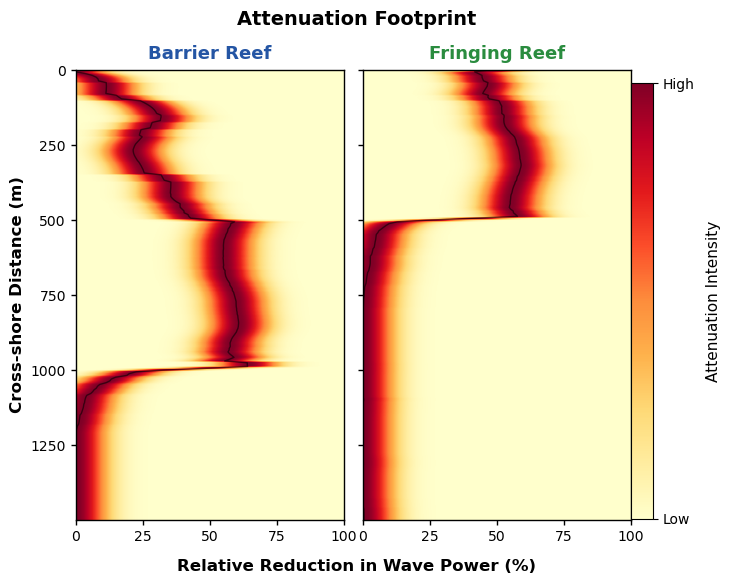

In [11]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# FILE PATHS
# ============================================================

dfsu_no_reef = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files"
    r"\small_scale_wave_result.dfsu"
)

dfsu_barrier = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\West_side_barrier_reef_1.5m_v2.sw - Result Files"
    r"\west_side_barrier_reef_1.5m_v2.dfsu"
)

dfsu_fringing = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\West_side_fringing_reef_v1.sw - Result Files"
    r"\west_side_fringing_reef_1.5m_v2.dfsu"
)

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# ============================================================
# TRANSECT
# ============================================================

# First point = coastline
# Second point = offshore end
x1, y1 = 730446.0, 3174401.0
x2, y2 = 731495.0, 3175473.0

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)

transect_xy = np.column_stack((x_line, y_line))

# Actual cumulative distance along transect
segment_lengths = np.sqrt(
    np.diff(x_line) ** 2 +
    np.diff(y_line) ** 2
)

distance = np.insert(
    np.cumsum(segment_lengths),
    0,
    0.0
)

print(
    f"Transect length = {distance[-1]:.2f} m"
)

# ============================================================
# USER PLOT SETTINGS
# ============================================================

# Reduction limits shown on x-axis
reduction_min = 0.0
reduction_max = 100.0

# Number of horizontal reduction bins
n_reduction_bins = 350

# Gaussian width controlling footprint thickness
# Increase this value for a broader footprint
footprint_sigma = 8.0

# Values below this threshold in the no-reef scenario
# are excluded to avoid division by very small numbers
denominator_tolerance = 1.0e-8

# Clip negative values:
# True  = plot attenuation only
# False = retain local wave-power amplification
clip_negative_reduction = True

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def find_item_name(dfs, requested_name):
    """
    Find the requested item using exact or partial matching.
    """

    available_items = [
        item.name for item in dfs.items
    ]

    for name in available_items:
        if name.strip().lower() == requested_name.strip().lower():
            return name

    possible_matches = [
        name for name in available_items
        if (
            "wave" in name.lower()
            and "power" in name.lower()
        )
    ]

    if len(possible_matches) == 1:
        print(
            f"Using item: {possible_matches[0]}"
        )
        return possible_matches[0]

    raise ValueError(
        f"Could not uniquely identify '{requested_name}'.\n"
        f"Available items:\n{available_items}"
    )


def get_nearest_time_index(dataset_time, requested_time):
    """
    Return the timestep nearest to the requested time.
    """

    time_array = np.asarray(
        dataset_time.values,
        dtype="datetime64[ns]"
    )

    requested_time = np.datetime64(
        requested_time,
        "ns"
    )

    index = np.argmin(
        np.abs(time_array - requested_time)
    )

    return index, time_array[index]


def interpolate_to_transect(
    data_array,
    time_index,
    target_xy
):
    """
    Interpolate an element-centered MIKE data array
    to the transect points.
    """

    geometry = data_array.geometry

    elem_ids, weights = geometry.get_2d_interpolant(
        target_xy,
        n_nearest=3,
        extrapolate=False
    )

    selected_data = data_array.isel(
        time=time_index
    )

    interpolated = geometry.interp2d(
        selected_data,
        elem_ids=elem_ids,
        weights=weights
    )

    values = np.asarray(
        interpolated
    ).squeeze()

    values = values.astype(float)

    # Remove MIKE delete values
    values[
        np.abs(values) > 1.0e30
    ] = np.nan

    return values


def calculate_reduction(
    no_reef_power,
    reef_power,
    tolerance=1.0e-8
):
    """
    Calculate relative wave-power reduction:

        ΔP = ((P_no reef - P_reef) / P_no reef) × 100
    """

    no_reef_power = np.asarray(
        no_reef_power,
        dtype=float
    )

    reef_power = np.asarray(
        reef_power,
        dtype=float
    )

    reduction = np.full_like(
        no_reef_power,
        np.nan,
        dtype=float
    )

    valid = (
        np.isfinite(no_reef_power)
        & np.isfinite(reef_power)
        & (np.abs(no_reef_power) > tolerance)
    )

    reduction[valid] = (
        (
            no_reef_power[valid]
            - reef_power[valid]
        )
        / no_reef_power[valid]
    ) * 100.0

    if clip_negative_reduction:
        reduction = np.where(
            np.isfinite(reduction),
            np.maximum(reduction, 0.0),
            np.nan
        )

    reduction = np.where(
        np.isfinite(reduction),
        np.minimum(reduction, 100.0),
        np.nan
    )

    return reduction


def interpolate_missing_profile_values(
    profile,
    profile_distance
):
    """
    Fill isolated missing values using linear interpolation.
    """

    profile = np.asarray(
        profile,
        dtype=float
    )

    profile_distance = np.asarray(
        profile_distance,
        dtype=float
    )

    valid = np.isfinite(profile)

    if np.sum(valid) < 2:
        raise ValueError(
            "Insufficient valid values along the transect."
        )

    filled_profile = np.interp(
        profile_distance,
        profile_distance[valid],
        profile[valid]
    )

    return filled_profile


def create_footprint_matrix(
    reduction_profile,
    reduction_axis,
    sigma
):
    """
    Convert a one-dimensional reduction profile into a
    two-dimensional footprint-style intensity matrix.

    At each cross-shore distance, a Gaussian distribution is
    centered at the local wave-power reduction value.
    """

    reduction_profile = np.asarray(
        reduction_profile,
        dtype=float
    )

    reduction_axis = np.asarray(
        reduction_axis,
        dtype=float
    )

    footprint = np.exp(
        -0.5
        * (
            (
                reduction_axis[None, :]
                - reduction_profile[:, None]
            )
            / sigma
        ) ** 2
    )

    # Normalize to 0–1
    footprint = footprint / np.nanmax(
        footprint
    )

    return footprint


# ============================================================
# OPEN FILES
# ============================================================

dfs_no_reef = mikeio.open(
    dfsu_no_reef
)

dfs_barrier = mikeio.open(
    dfsu_barrier
)

dfs_fringing = mikeio.open(
    dfsu_fringing
)

# Identify wave-power item
item_no_reef = find_item_name(
    dfs_no_reef,
    item_name
)

item_barrier = find_item_name(
    dfs_barrier,
    item_name
)

item_fringing = find_item_name(
    dfs_fringing,
    item_name
)

# Read datasets
ds_no_reef = dfs_no_reef.read(
    items=[item_no_reef]
)

ds_barrier = dfs_barrier.read(
    items=[item_barrier]
)

ds_fringing = dfs_fringing.read(
    items=[item_fringing]
)

p_no_reef_all = ds_no_reef[0]
p_barrier_all = ds_barrier[0]
p_fringing_all = ds_fringing[0]

# ============================================================
# FIND NEAREST TIMESTEP IN EACH SIMULATION
# ============================================================

index_no_reef, selected_no_reef_time = (
    get_nearest_time_index(
        ds_no_reef.time,
        target_time
    )
)

index_barrier, selected_barrier_time = (
    get_nearest_time_index(
        ds_barrier.time,
        target_time
    )
)

index_fringing, selected_fringing_time = (
    get_nearest_time_index(
        ds_fringing.time,
        target_time
    )
)

print("\nSelected times")
print(
    f"No reef:      {selected_no_reef_time}"
)
print(
    f"Barrier reef: {selected_barrier_time}"
)
print(
    f"Fringing reef:{selected_fringing_time}"
)

# ============================================================
# INTERPOLATE WAVE POWER TO TRANSECT
# ============================================================

p_no_reef = interpolate_to_transect(
    data_array=p_no_reef_all,
    time_index=index_no_reef,
    target_xy=transect_xy
)

p_barrier = interpolate_to_transect(
    data_array=p_barrier_all,
    time_index=index_barrier,
    target_xy=transect_xy
)

p_fringing = interpolate_to_transect(
    data_array=p_fringing_all,
    time_index=index_fringing,
    target_xy=transect_xy
)

# ============================================================
# CALCULATE RELATIVE REDUCTION
# ============================================================

barrier_reduction = calculate_reduction(
    no_reef_power=p_no_reef,
    reef_power=p_barrier,
    tolerance=denominator_tolerance
)

fringing_reduction = calculate_reduction(
    no_reef_power=p_no_reef,
    reef_power=p_fringing,
    tolerance=denominator_tolerance
)

# Fill isolated missing points for smooth plotting
barrier_reduction_smooth = (
    interpolate_missing_profile_values(
        barrier_reduction,
        distance
    )
)

fringing_reduction_smooth = (
    interpolate_missing_profile_values(
        fringing_reduction,
        distance
    )
)

print("\nWave-power reduction results")

print(
    f"Barrier mean reduction: "
    f"{np.nanmean(barrier_reduction):.2f}%"
)

print(
    f"Barrier maximum reduction: "
    f"{np.nanmax(barrier_reduction):.2f}%"
)

print(
    f"Fringing mean reduction: "
    f"{np.nanmean(fringing_reduction):.2f}%"
)

print(
    f"Fringing maximum reduction: "
    f"{np.nanmax(fringing_reduction):.2f}%"
)

# ============================================================
# CREATE ATTENUATION FOOTPRINT MATRICES
# ============================================================

reduction_axis = np.linspace(
    reduction_min,
    reduction_max,
    n_reduction_bins
)

barrier_footprint = create_footprint_matrix(
    reduction_profile=barrier_reduction_smooth,
    reduction_axis=reduction_axis,
    sigma=footprint_sigma
)

fringing_footprint = create_footprint_matrix(
    reduction_profile=fringing_reduction_smooth,
    reduction_axis=reduction_axis,
    sigma=footprint_sigma
)

# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(7.4, 6.0),
    sharey=True,
    gridspec_kw={
        "wspace": 0.07
    }
)

# Common plot extent
extent = [
    reduction_min,
    reduction_max,
    distance[-1],
    0.0
]

# ------------------------------------------------------------
# Barrier reef
# ------------------------------------------------------------

image_1 = axes[0].imshow(
    barrier_footprint,
    extent=extent,
    origin="upper",
    aspect="auto",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    interpolation="bilinear"
)

axes[0].set_title(
    "Barrier Reef",
    fontsize=13,
    fontweight="bold",
    color="#2455A4",
    pad=8
)

axes[0].set_ylabel(
    "Cross-shore Distance (m)",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_xlim(
    reduction_min,
    reduction_max
)

axes[0].set_xticks(
    [0, 25, 50, 75, 100]
)

axes[0].set_yticks(
    np.arange(
        0,
        distance[-1] + 1,
        250
    )
)

# Optional profile line
axes[0].plot(
    barrier_reduction_smooth,
    distance,
    color="black",
    linewidth=1.0,
    alpha=0.55
)

# ------------------------------------------------------------
# Fringing reef
# ------------------------------------------------------------

image_2 = axes[1].imshow(
    fringing_footprint,
    extent=extent,
    origin="upper",
    aspect="auto",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    interpolation="bilinear"
)

axes[1].set_title(
    "Fringing Reef",
    fontsize=13,
    fontweight="bold",
    color="#2A8C3F",
    pad=8
)

axes[1].set_xlim(
    reduction_min,
    reduction_max
)

axes[1].set_xticks(
    [0, 25, 50, 75, 100]
)

# Optional profile line
axes[1].plot(
    fringing_reduction_smooth,
    distance,
    color="black",
    linewidth=1.0,
    alpha=0.55
)

# ------------------------------------------------------------
# Common formatting
# ------------------------------------------------------------

for ax in axes:

    ax.tick_params(
        axis="both",
        labelsize=10,
        width=1
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

fig.suptitle(
    "Attenuation Footprint",
    fontsize=14,
    fontweight="bold",
    y=0.98
)

fig.supxlabel(
    "Relative Reduction in Wave Power (%)",
    fontsize=12,
    fontweight="bold",
    y=0.04
)

# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(
    image_2,
    ax=axes,
    orientation="vertical",
    fraction=0.038,
    pad=2
)

cbar.set_ticks(
    [0, 1]
)

cbar.set_ticklabels(
    ["Low", "High"]
)

cbar.ax.tick_params(
    labelsize=10
)

cbar.set_label(
    "Attenuation Intensity",
    fontsize=11,
    labelpad=8
)

# ============================================================
# SAVE AND DISPLAY
# ============================================================

# output_figure = (
#     r"D:\Phd Research\Wave Model\small scale port lavaca"
#     r"\Simulation\West_Barrier_Fringing_Attenuation_Footprint.png"
# )

plt.subplots_adjust(
    left=0.12,
    right=0.87,
    bottom=0.13,
    top=0.88
)

plt.savefig(
    output_figure,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# print(
#     f"\nFigure saved to:\n{output_figure}"
# )

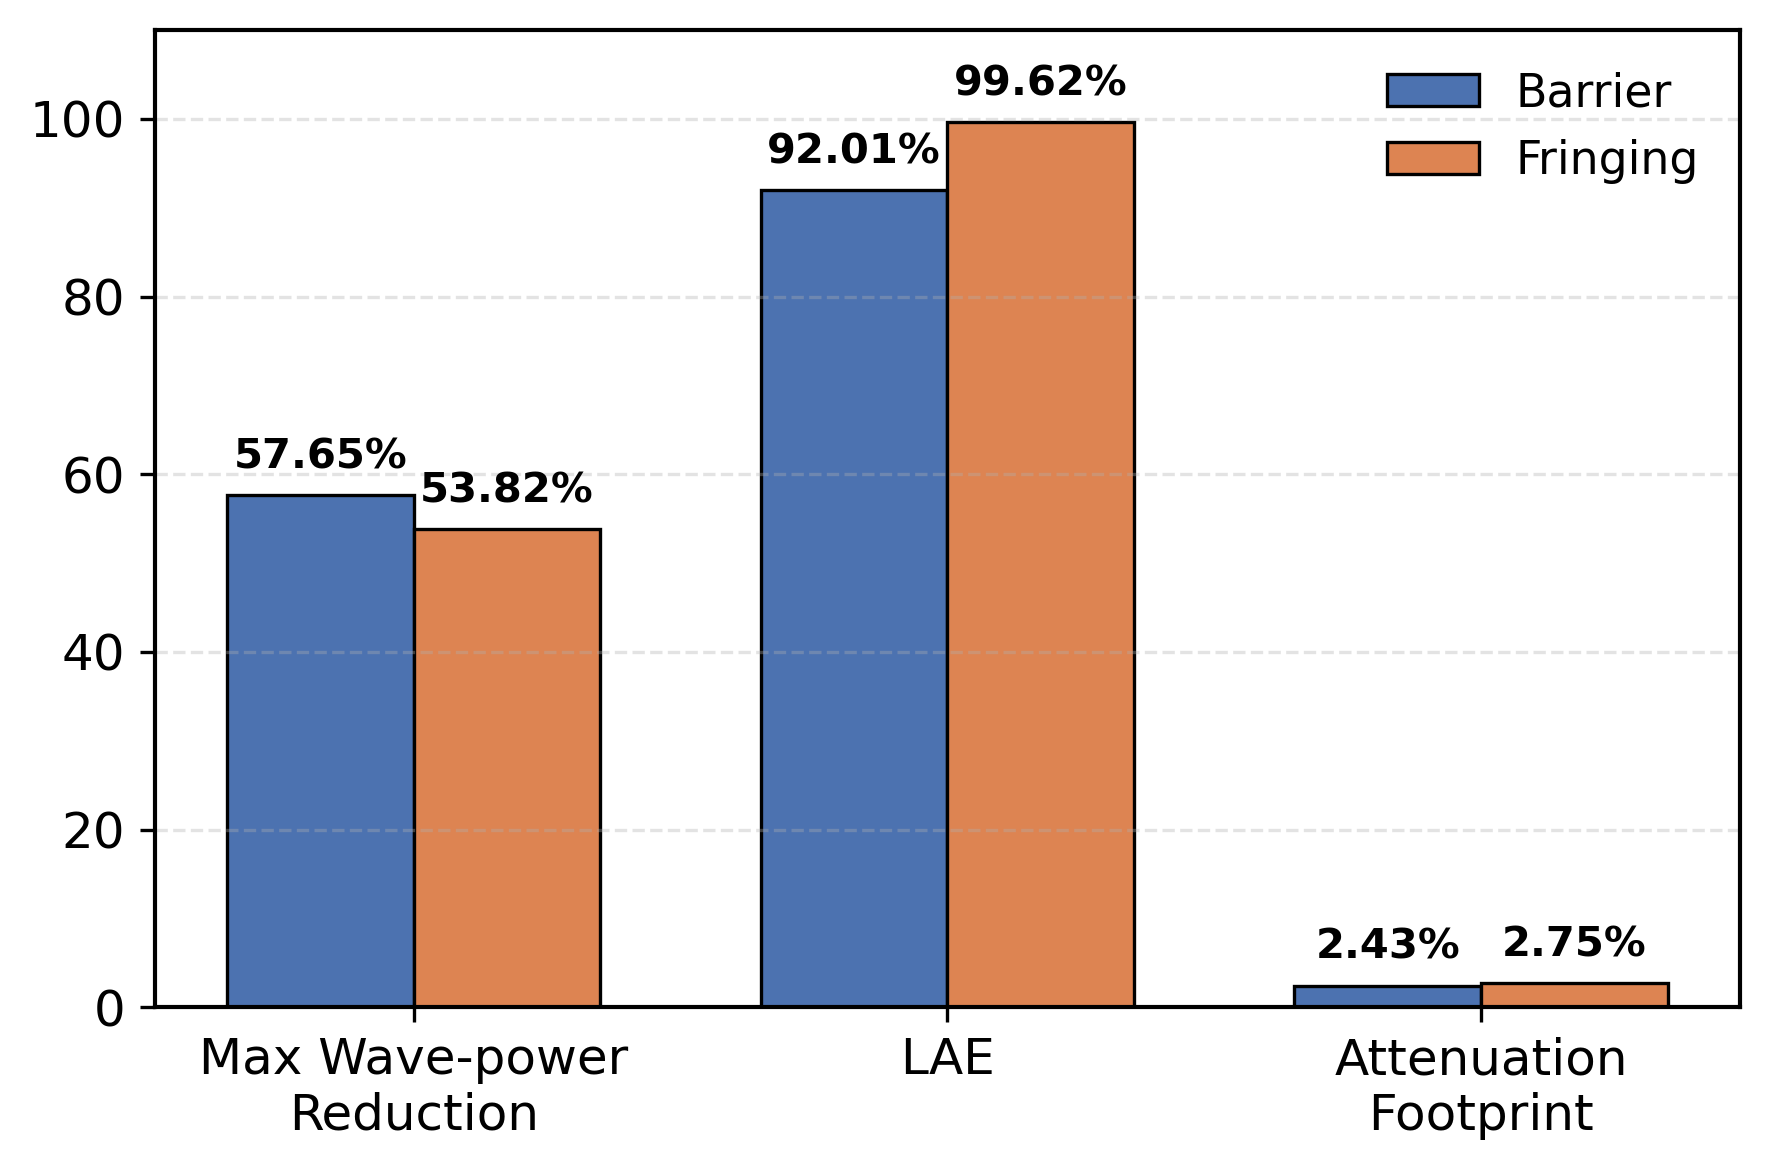

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Data
categories = ["Max Wave-power\nReduction", "LAE", "Attenuation\nFootprint"]
barrier = [57.65, 92.01, 2.43]
fringing = [53.82, 99.62, 2.75]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(6,4), dpi=300)

b1 = ax.bar(x-width/2, barrier, width, color="#4C72B0", edgecolor="black", linewidth=0.8, label="Barrier")
b2 = ax.bar(x+width/2, fringing, width, color="#DD8452", edgecolor="black", linewidth=0.8, label="Fringing")

# ax.set_ylabel("Percentage (%)", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0,110)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(frameon=False, fontsize=11)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+2, f"{h:.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()
# plt.savefig("Barrier_vs_Fringing_Comparison.png", dpi=600, bbox_inches="tight")
plt.show()